<a href="https://colab.research.google.com/github/juli-ter/COINS/blob/main/Shield_Adaptation_RT_LMM_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Shield-size adaptation latency around noise changepoints

This notebook analyses **shield adaptation reaction time (adaptation RT)** extracted around noise changepoints.

Each row of the input file corresponds to one noise changepoint. Adaptation RT is defined as the first post-changepoint time at which the normalized shield-size change reaches **50% of its subsequent peak change**.

The primary linear mixed-effects model is:

log(adaptation RT) ~ volatility × direction + noise jump size + (1 | subject)

where:

- `volatility`: stable vs. volatile environment
- `direction`: noise increase vs. noise decrease
- `noise_jump_size_z`: standardized magnitude of the noise transition (10 vs. 20 degrees)
- `(1 | subject)`: participant-specific random intercept

Because adaptation RT is positive and right-skewed, it is log-transformed before modelling.

**Important:** only rows with `valid_for_model == TRUE` are used in the RT LMM. Since a substantial number of events may not yield a valid half-peak crossing, the notebook also includes an optional logistic mixed model testing whether the probability of obtaining a valid adaptation RT depends on the experimental conditions.


In [ ]:
install.packages(c(
  "lme4",
  "lmerTest",
  "emmeans",
  "performance",
  "see",
  "broom.mixed",
  "patchwork"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘rbibutils’, ‘future’, ‘globals’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘numDeriv’, ‘estimability’, ‘mvtnorm’, ‘bayestestR’, ‘insight’, ‘datawizard’, ‘correlation’, ‘effectsize’, ‘modelbased’, ‘parameters’, ‘coda’, ‘furrr’




In [ ]:
library(tidyverse)
library(lme4)
library(lmerTest)
library(emmeans)
library(performance)
library(see)
library(broom.mixed)
library(patchwork)

options(
  repr.plot.width = 12,
  repr.plot.height = 7,
  repr.plot.res = 150
)

theme_set(theme_minimal(base_size = 15))


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



## 1. Load the adaptation-RT dataset

In [ ]:

data_path <- "noise_changepoint_shield_adaptation_rt_pre_5s_post_15s.csv"

dataset <- read_csv(
  data_path,
  show_col_types = FALSE
)

cat("Rows:", nrow(dataset), "\n")
cat("Participants:", n_distinct(dataset$subject), "\n\n")

glimpse(dataset)


Rows: 3267 
Participants: 22 

Rows: 3,267
Columns: 16
$ subject           <chr> "sub-01", "sub-01", "sub-01", "sub-01", "sub-01", "s…
$ sessID            <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ blockID           <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2…
$ noise_cp_frame    <dbl> 1354, 2179, 2736, 3480, 4231, 5873, 6397, 7341, 8076…
$ old_noise         <dbl> 20, 10, 30, 10, 30, 10, 20, 30, 20, 10, 30, 20, 10, …
$ new_noise         <dbl> 10, 30, 10, 30, 10, 20, 30, 20, 10, 30, 10, 10, 30, …
$ noise_transition  <chr> "20->10", "10->30", "30->10", "10->30", "30->10", "1…
$ direction         <chr> "noise decrease", "noise increase", "noise decrease"…
$ volatility_label  <chr> "Stable", "Stable", "Stable", "Stable", "Stable", "S…
$ noise_jump_size   <dbl> 10, 20, 20, 20, 20, 10, 10, 10, 10, 20, 20, 10, 20, …
$ peak_change       <dbl> 0, 0, -20, 20, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 20, 0, …
$ peak_time         <dbl> 0.000000, 0.000000, 9.716667, 2.300000,

## 2. Prepare factors and model datasets

In [ ]:

adapt_all <- dataset %>%
  mutate(
    subject = factor(subject),

    volatility = factor(
      tolower(trimws(as.character(volatility_label))),
      levels = c("stable", "volatile")
    ),

    direction = case_when(
      tolower(trimws(as.character(direction))) == "noise increase" ~ "increase",
      tolower(trimws(as.character(direction))) == "noise decrease" ~ "decrease",
      TRUE ~ NA_character_
    ),

    direction = factor(
      direction,
      levels = c("increase", "decrease")
    ),

    noise_transition = factor(
      noise_transition,
      levels = c(
        "10->20", "20->30", "10->30",
        "30->20", "20->10", "30->10"
      )
    )
  )

adapt_rt <- adapt_all %>%
  filter(
    valid_for_model,
    crossed_half_peak,
    !is.na(adaptation_rt),
    is.finite(adaptation_rt),
    adaptation_rt > 0,
    !is.na(subject),
    !is.na(volatility),
    !is.na(direction),
    !is.na(noise_jump_size)
  ) %>%
  mutate(
    log_adaptation_rt = log(adaptation_rt),
    noise_jump_size_z = as.numeric(scale(noise_jump_size))
  )

# Sum coding for Type-III factorial tests.
# With the level order above:
# stable   = +1, volatile = -1
# increase = +1, decrease = -1
contrasts(adapt_rt$volatility) <- contr.sum(2)
contrasts(adapt_rt$direction) <- contr.sum(2)

cat("All noise changepoints:", nrow(adapt_all), "\n")
cat("Valid rows used in LMM:", nrow(adapt_rt), "\n")
cat(
  "Proportion valid:",
  round(nrow(adapt_rt) / nrow(adapt_all), 3),
  "\n"
)
cat("Participants in LMM:", n_distinct(adapt_rt$subject), "\n")


All noise changepoints: 3267 
Valid rows used in LMM: 1842 
Proportion valid: 0.564 
Participants in LMM: 22 


## 3. Data-quality and descriptive summaries

In [ ]:

# Valid / invalid event counts
adapt_all %>%
  count(volatility, direction, valid_for_model) %>%
  arrange(volatility, direction, valid_for_model)


volatility,direction,valid_for_model,n
<fct>,<fct>,<lgl>,<int>
stable,increase,FALSE,308
stable,increase,TRUE,525
stable,decrease,FALSE,336
stable,decrease,TRUE,475
volatile,increase,FALSE,356
volatile,increase,TRUE,465
volatile,decrease,FALSE,425
volatile,decrease,TRUE,377


In [ ]:

# Number of usable observations for every transition
adapt_rt %>%
  count(
    volatility,
    direction,
    noise_transition,
    name = "n"
  ) %>%
  arrange(direction, noise_transition, volatility)


volatility,direction,noise_transition,n
<fct>,<fct>,<fct>,<int>
stable,increase,10->20,282
volatile,increase,10->20,236
stable,increase,20->30,66
volatile,increase,20->30,58
stable,increase,10->30,177
volatile,increase,10->30,171
stable,decrease,30->20,68
volatile,decrease,30->20,64
stable,decrease,20->10,238


In [ ]:

# Descriptive adaptation RT statistics
adapt_rt %>%
  group_by(volatility, direction) %>%
  summarise(
    n = n(),
    mean_rt = mean(adaptation_rt),
    median_rt = median(adaptation_rt),
    sd_rt = sd(adaptation_rt),
    mean_peak_time = mean(peak_time),
    mean_peak_change = mean(peak_change),
    .groups = "drop"
  )


volatility,direction,n,mean_rt,median_rt,sd_rt,mean_peak_time,mean_peak_change
<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
stable,increase,525,2.988032,2.275000,2.383420,3.614762,24.76190
stable,decrease,475,3.588632,3.041667,2.593027,4.157930,-23.66316
volatile,increase,465,3.061900,2.600000,2.339782,3.715699,24.60215
volatile,decrease,377,3.813484,3.225000,2.625145,4.379664,-23.97878


## 4. Distribution of adaptation RT

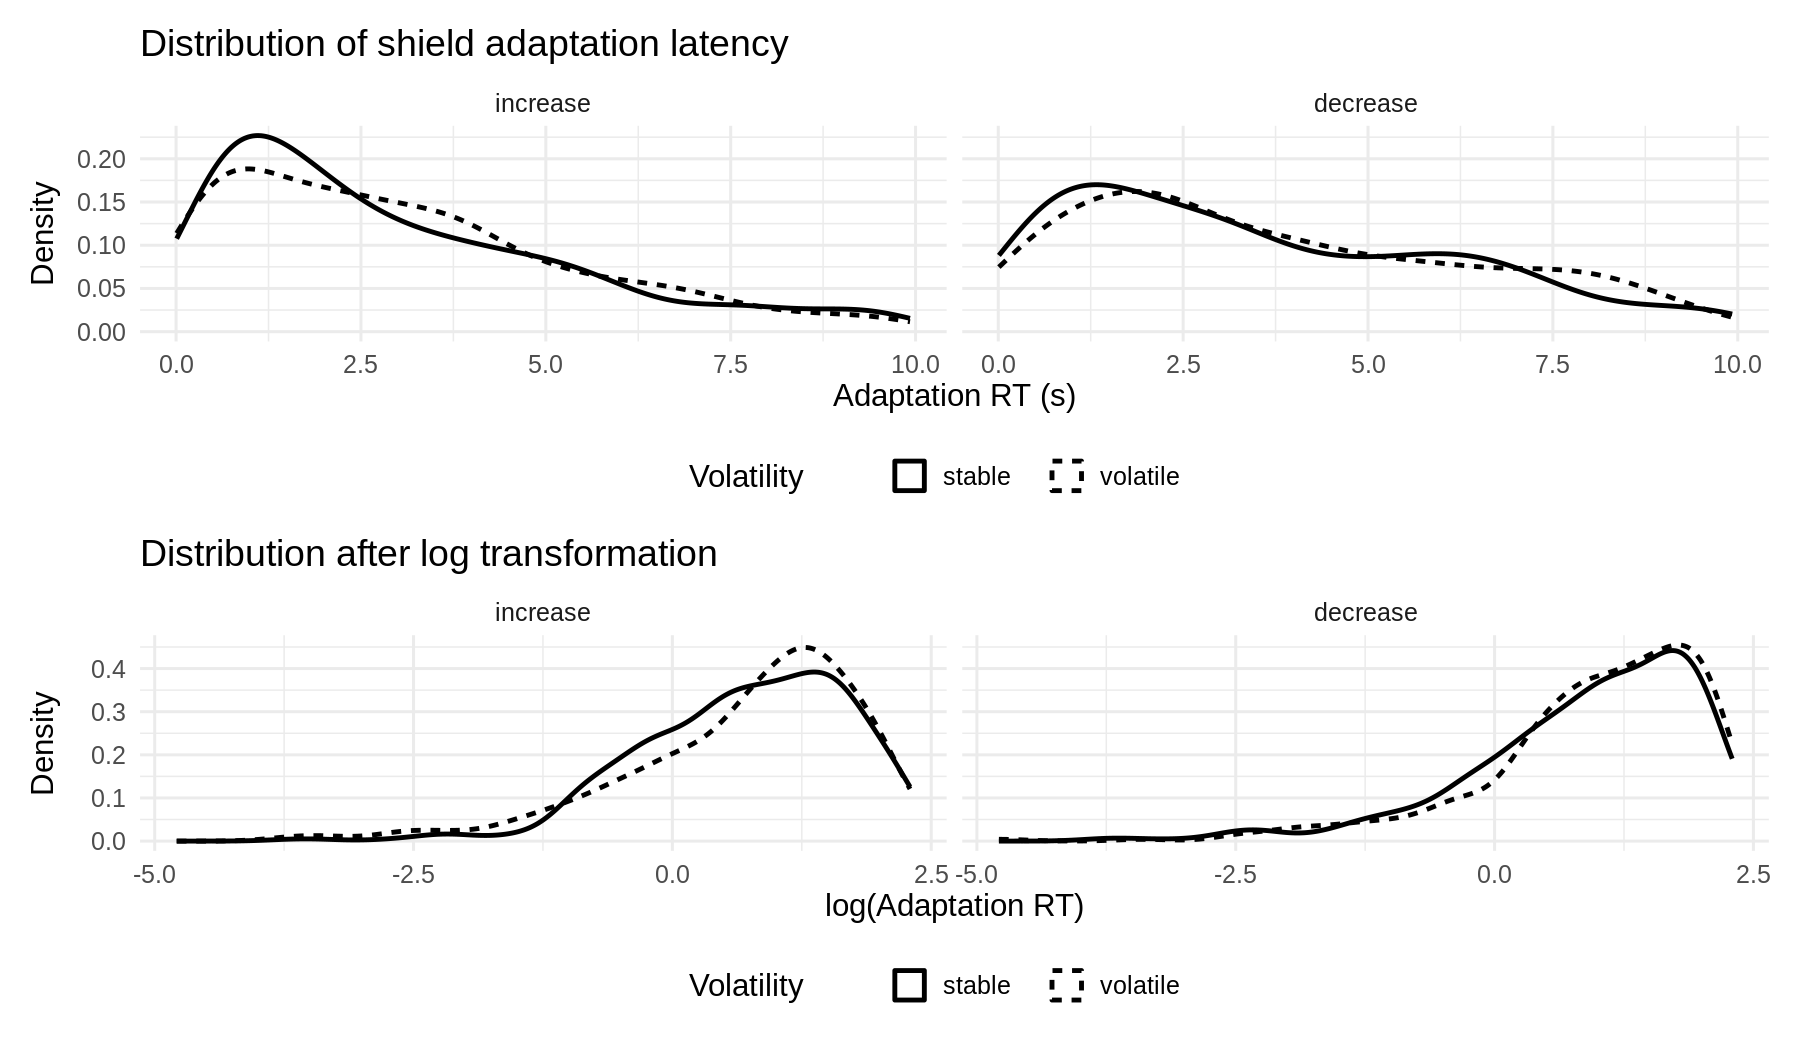

In [ ]:

p_raw_density <- ggplot(
  adapt_rt,
  aes(
    x = adaptation_rt,
    linetype = volatility
  )
) +
  geom_density(
    linewidth = 1.1
  ) +
  facet_wrap(
    ~ direction,
    nrow = 1
  ) +
  labs(
    title = "Distribution of shield adaptation latency",
    x = "Adaptation RT (s)",
    y = "Density",
    linetype = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_log_density <- ggplot(
  adapt_rt,
  aes(
    x = log_adaptation_rt,
    linetype = volatility
  )
) +
  geom_density(
    linewidth = 1.1
  ) +
  facet_wrap(
    ~ direction,
    nrow = 1
  ) +
  labs(
    title = "Distribution after log transformation",
    x = "log(Adaptation RT)",
    y = "Density",
    linetype = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_raw_density / p_log_density


## 5. Raw adaptation RT by experimental condition

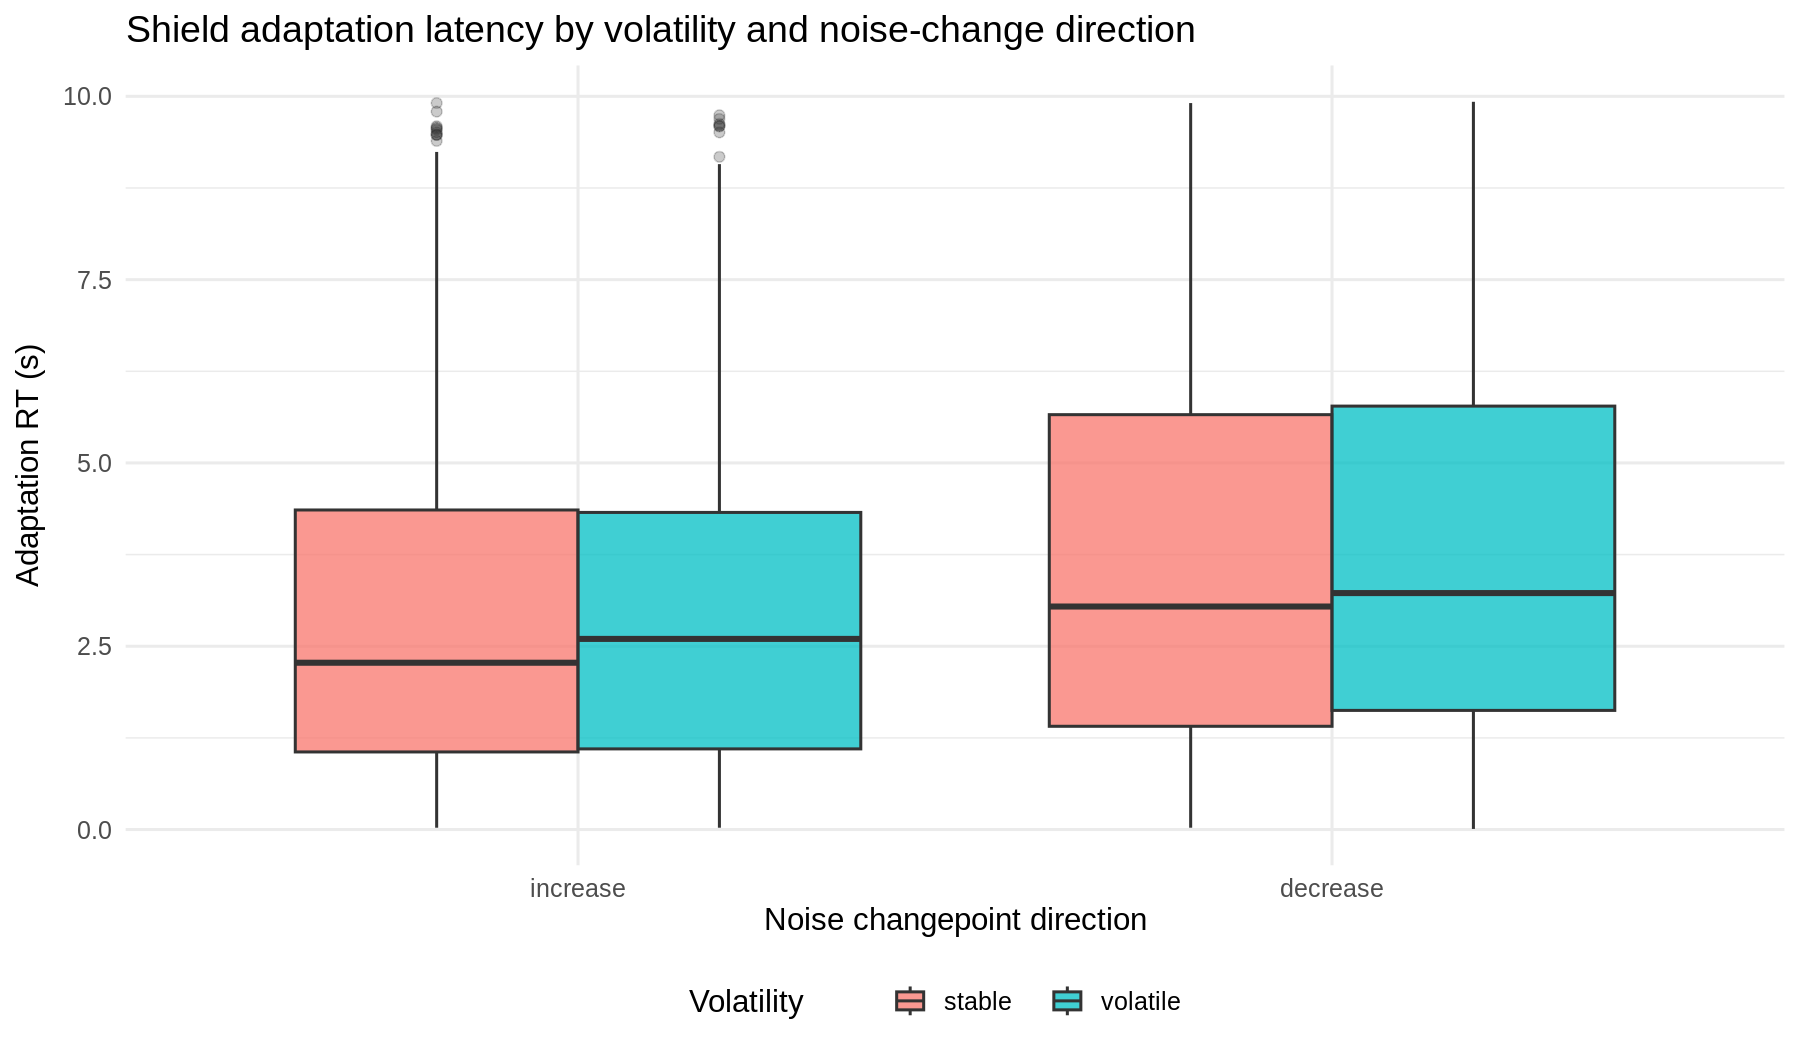

In [ ]:

p_box <- ggplot(
  adapt_rt,
  aes(
    x = direction,
    y = adaptation_rt,
    fill = volatility
  )
) +
  geom_boxplot(
    alpha = 0.75,
    outlier.alpha = 0.25,
    position = position_dodge(width = 0.75)
  ) +
  labs(
    title = "Shield adaptation latency by volatility and noise-change direction",
    x = "Noise changepoint direction",
    y = "Adaptation RT (s)",
    fill = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_box


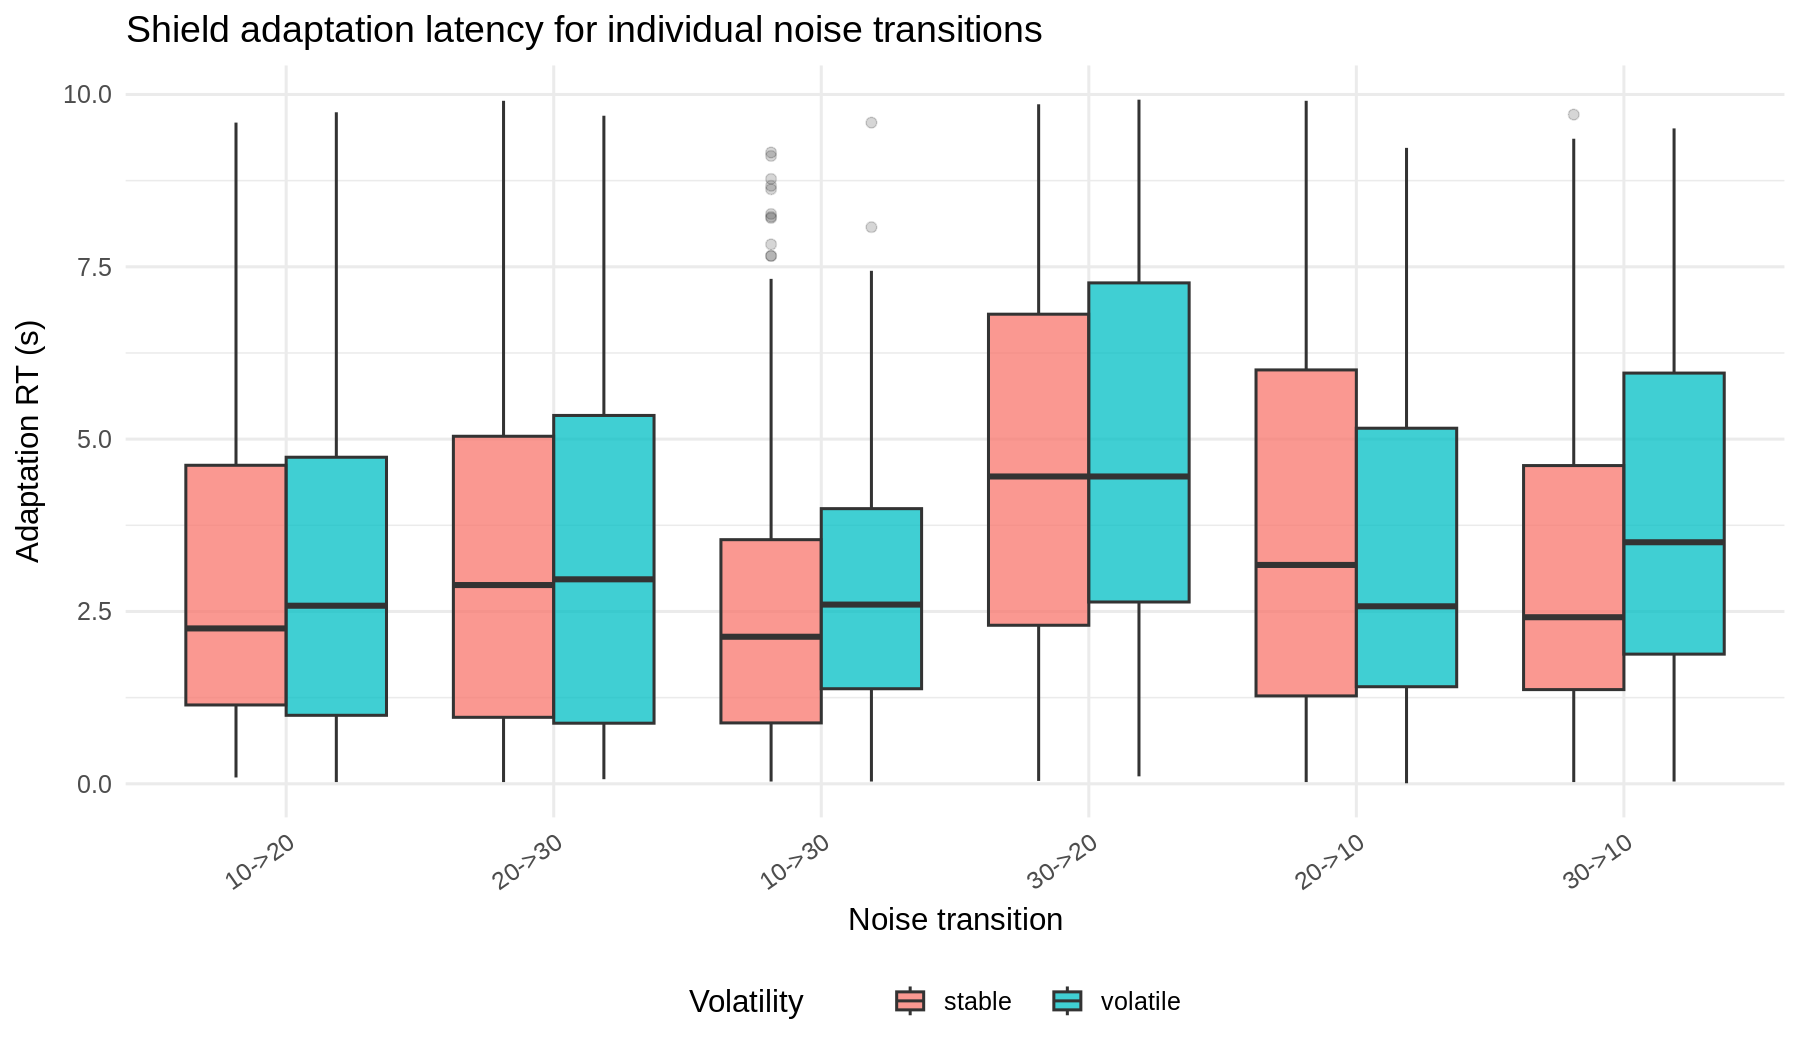

In [ ]:

p_transition <- ggplot(
  adapt_rt,
  aes(
    x = noise_transition,
    y = adaptation_rt,
    fill = volatility
  )
) +
  geom_boxplot(
    alpha = 0.75,
    outlier.alpha = 0.20,
    position = position_dodge(width = 0.75)
  ) +
  labs(
    title = "Shield adaptation latency for individual noise transitions",
    x = "Noise transition",
    y = "Adaptation RT (s)",
    fill = "Volatility"
  ) +
  theme(
    legend.position = "bottom",
    axis.text.x = element_text(
      angle = 35,
      hjust = 1
    )
  )

p_transition


## 6. Valid adaptation-RT probability

volatility,direction,n,valid_n,valid_probability
<fct>,<fct>,<int>,<int>,<dbl>
stable,increase,833,525,0.6302521
stable,decrease,811,475,0.5856967
volatile,increase,821,465,0.5663825
volatile,decrease,802,377,0.4700748


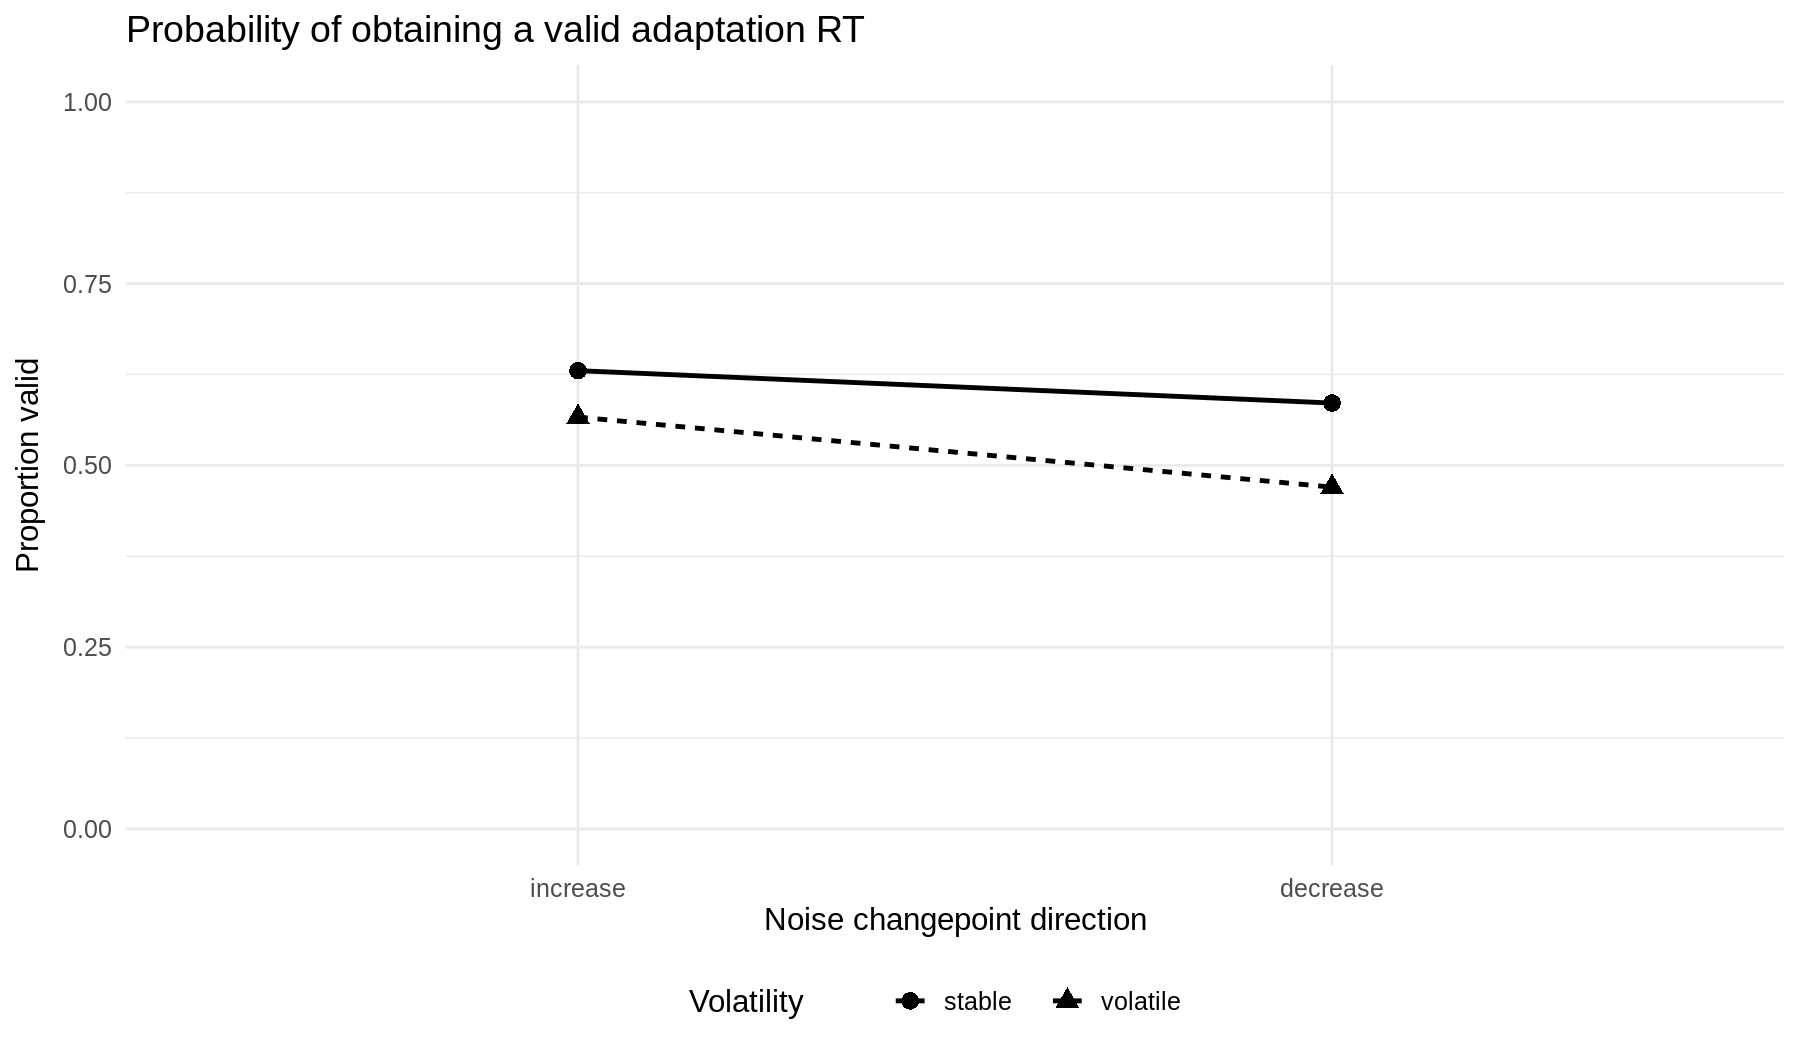

In [ ]:

valid_summary <- adapt_all %>%
  filter(
    !is.na(volatility),
    !is.na(direction)
  ) %>%
  group_by(
    volatility,
    direction
  ) %>%
  summarise(
    n = n(),
    valid_n = sum(valid_for_model, na.rm = TRUE),
    valid_probability = mean(valid_for_model, na.rm = TRUE),
    .groups = "drop"
  )

valid_summary

p_valid <- ggplot(
  valid_summary,
  aes(
    x = direction,
    y = valid_probability,
    group = volatility,
    linetype = volatility,
    shape = volatility
  )
) +
  geom_line(
    linewidth = 1.1
  ) +
  geom_point(
    size = 3.5
  ) +
  scale_y_continuous(
    limits = c(0, 1)
  ) +
  labs(
    title = "Probability of obtaining a valid adaptation RT",
    x = "Noise changepoint direction",
    y = "Proportion valid",
    linetype = "Volatility",
    shape = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_valid


## 7. Participant-level trajectories

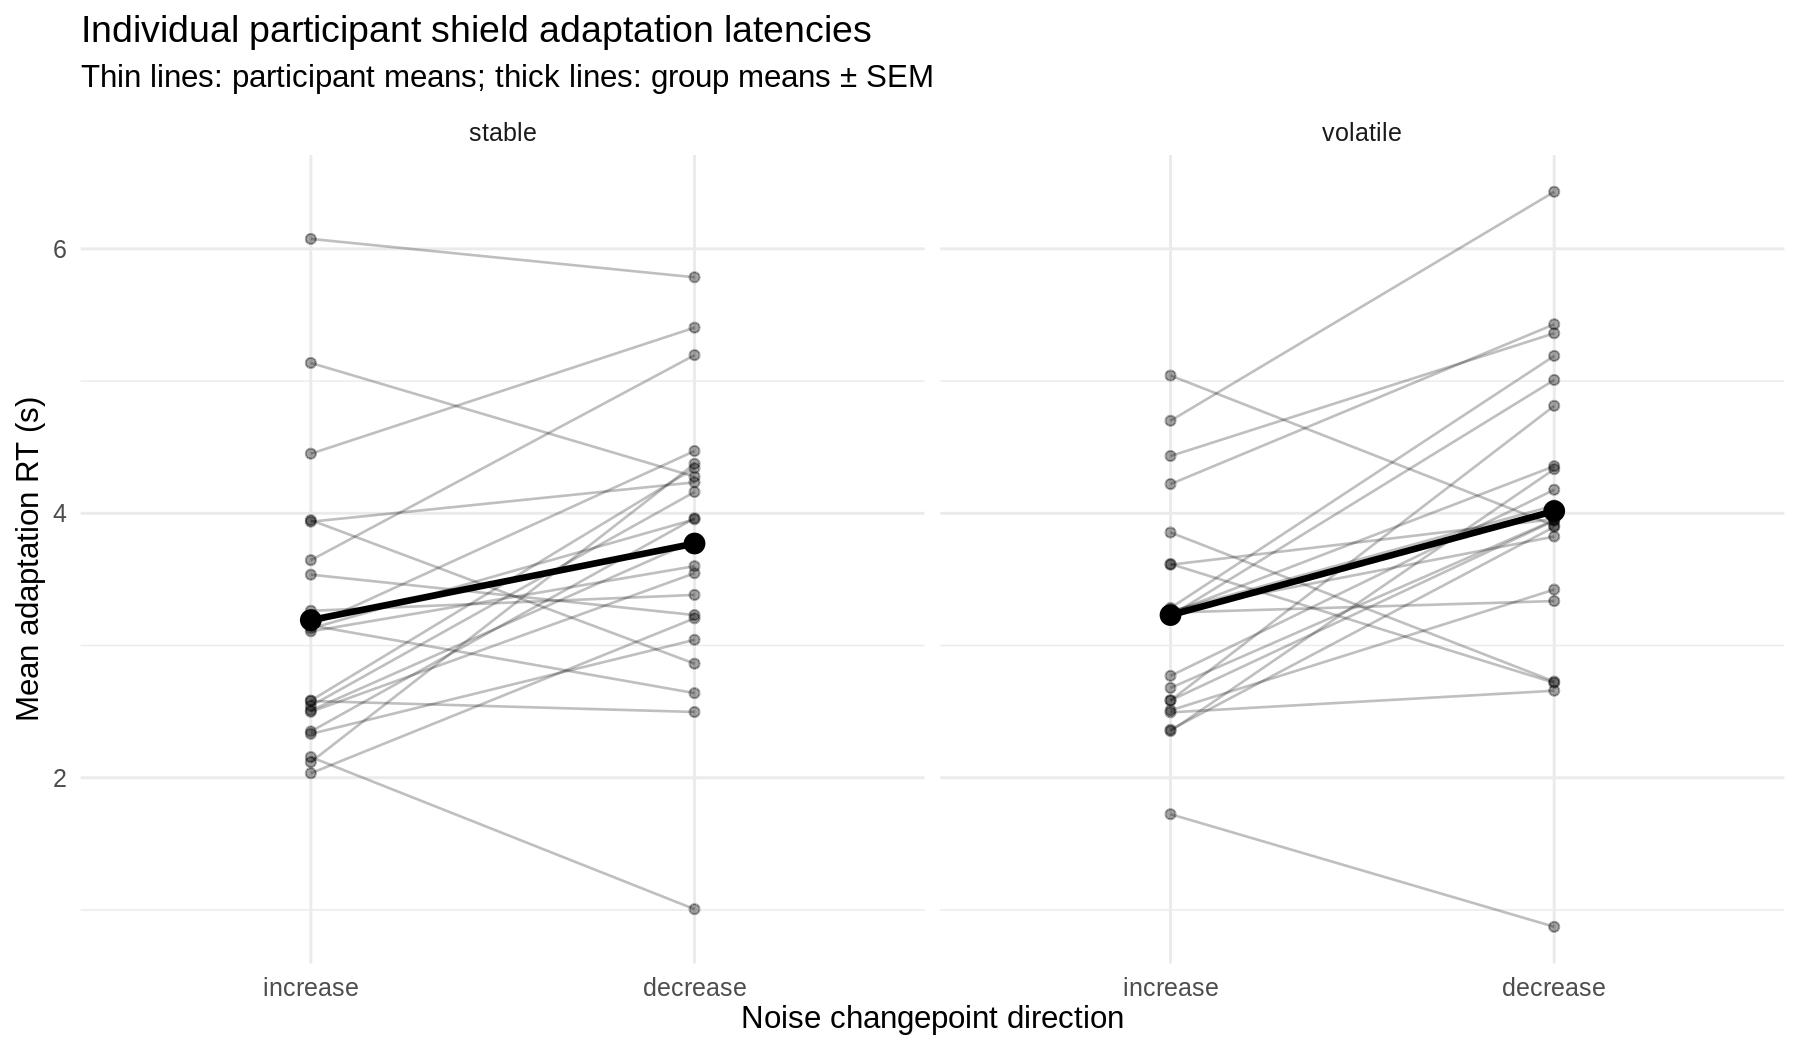

In [ ]:

participant_means <- adapt_rt %>%
  group_by(
    subject,
    volatility,
    direction
  ) %>%
  summarise(
    mean_rt = mean(adaptation_rt),
    .groups = "drop"
  )

group_means <- participant_means %>%
  group_by(
    volatility,
    direction
  ) %>%
  summarise(
    mean_rt = mean(mean_rt),
    sem_rt = sd(mean_rt) / sqrt(n()),
    .groups = "drop"
  )

p_participants <- ggplot() +
  geom_line(
    data = participant_means,
    aes(
      x = direction,
      y = mean_rt,
      group = subject
    ),
    alpha = 0.25,
    linewidth = 0.6
  ) +
  geom_point(
    data = participant_means,
    aes(
      x = direction,
      y = mean_rt
    ),
    alpha = 0.35,
    size = 1.8
  ) +
  geom_line(
    data = group_means,
    aes(
      x = direction,
      y = mean_rt,
      group = 1
    ),
    linewidth = 1.5
  ) +
  geom_point(
    data = group_means,
    aes(
      x = direction,
      y = mean_rt
    ),
    size = 4
  ) +
  geom_errorbar(
    data = group_means,
    aes(
      x = direction,
      ymin = mean_rt - sem_rt,
      ymax = mean_rt + sem_rt
    ),
    width = 0.08,
    linewidth = 0.9
  ) +
  facet_wrap(
    ~ volatility
  ) +
  labs(
    title = "Individual participant shield adaptation latencies",
    subtitle = "Thin lines: participant means; thick lines: group means ± SEM",
    x = "Noise changepoint direction",
    y = "Mean adaptation RT (s)"
  )

p_participants


## 8. Primary linear mixed-effects model

In [ ]:

model_adapt_rt <- lmer(
  log_adaptation_rt ~
    volatility * direction +
    noise_jump_size_z +
    (1 | subject),
  data = adapt_rt,
  REML = FALSE
)

summary(model_adapt_rt)


Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: log_adaptation_rt ~ volatility * direction + noise_jump_size_z +  
    (1 | subject)
   Data: adapt_rt

      AIC       BIC    logLik -2*log(L)  df.resid 
   5342.8    5381.5   -2664.4    5328.8      1835 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.7769 -0.5261  0.1724  0.7075  2.2408 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.0889   0.2982  
 Residual             1.0311   1.0154  
Number of obs: 1842, groups:  subject, 22

Fixed effects:
                         Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)               0.87424    0.06863   21.53433  12.739 1.69e-11 ***
volatility1              -0.03038    0.02399 1827.56682  -1.266    0.206    
direction1               -0.10549    0.02389 1822.15930  -4.416 1.07e-05 ***
noise_jump_size_z        -0.03903    0.02373 1822.44161  -1.645    0.100    
v


### Interpretation of the coding

Because sum contrasts are used:

- `volatility1` is half of the **stable − volatile** contrast, averaged across direction.
- `direction1` is half of the **increase − decrease** contrast, averaged across volatility.
- `volatility1:direction1` tests whether the volatility effect differs between increase and decrease changepoints.
- `noise_jump_size_z` tests whether larger changes in noise magnitude are associated with longer or shorter adaptation latency.

Because the dependent variable is log-transformed, positive coefficients indicate longer adaptation RT and negative coefficients indicate shorter adaptation RT.


## 9. Type-III omnibus tests

In [ ]:

anova_adapt_rt <- anova(
  model_adapt_rt,
  type = 3,
  ddf = "Satterthwaite"
)

anova_adapt_rt


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
volatility,1.653483,1.653483,1,1827.567,1.603621,2.055521e-01
direction,20.104620,20.104620,1,1822.159,19.498358,1.065939e-05
noise_jump_size_z,2.788612,2.788612,1,1822.442,2.704520,1.002366e-01
volatility:direction,1.125047,1.125047,1,1821.084,1.091121,2.963616e-01


## 10. Estimated marginal means and post-hoc comparisons

In [ ]:

emm_adapt_log <- emmeans(
  model_adapt_rt,
  ~ volatility * direction,
  at = list(
    noise_jump_size_z = 0
  ),
  lmer.df = "satterthwaite"
)

emm_adapt_ci <- as.data.frame(
  confint(emm_adapt_log)
)

# Works with either Satterthwaite or asymptotic CI names.
lower_name <- if (
  "lower.CL" %in% names(emm_adapt_ci)
) {
  "lower.CL"
} else {
  "asymp.LCL"
}

upper_name <- if (
  "upper.CL" %in% names(emm_adapt_ci)
) {
  "upper.CL"
} else {
  "asymp.UCL"
}

emm_adapt <- emm_adapt_ci %>%
  mutate(
    predicted_rt = exp(emmean),
    lower_rt = exp(.data[[lower_name]]),
    upper_rt = exp(.data[[upper_name]])
  )

emm_adapt %>%
  select(
    volatility,
    direction,
    predicted_rt,
    lower_rt,
    upper_rt
  )


,volatility,direction,predicted_rt,lower_rt,upper_rt
,<fct>,<fct>,<dbl>,<dbl>,<dbl>
1,stable,increase,2.145320,1.831574,2.512812
2,volatile,increase,2.168848,1.845016,2.549518
3,stable,decrease,2.520428,2.146787,2.959100
4,volatile,decrease,2.815207,2.380686,3.329036


In [ ]:

# Stable vs volatile separately for increase/decrease
posthoc_volatility <- emmeans(
  model_adapt_rt,
  ~ volatility | direction,
  at = list(
    noise_jump_size_z = 0
  )
) %>%
  pairs(
    adjust = "holm"
  ) %>%
  as.data.frame()

posthoc_volatility


Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed



,contrast,direction,estimate,SE,df,t.ratio,p.value
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stable - volatile,increase,-0.01090729,0.06492131,1824.331,-0.1680079,0.8665957
2,stable - volatile,decrease,-0.11060712,0.07031411,1824.622,-1.5730430,0.1158822


In [ ]:

# Increase vs decrease separately for stable/volatile
posthoc_direction <- emmeans(
  model_adapt_rt,
  ~ direction | volatility,
  at = list(
    noise_jump_size_z = 0
  )
) %>%
  pairs(
    adjust = "holm"
  ) %>%
  as.data.frame()

posthoc_direction


Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed



,contrast,volatility,estimate,SE,df,t.ratio,p.value
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,increase - decrease,stable,-0.1611397,0.06439231,1821.027,-2.502467,0.0124201417
2,increase - decrease,volatile,-0.2608395,0.07053222,1822.118,-3.698161,0.0002235995


## 11. Model-estimated interaction plot

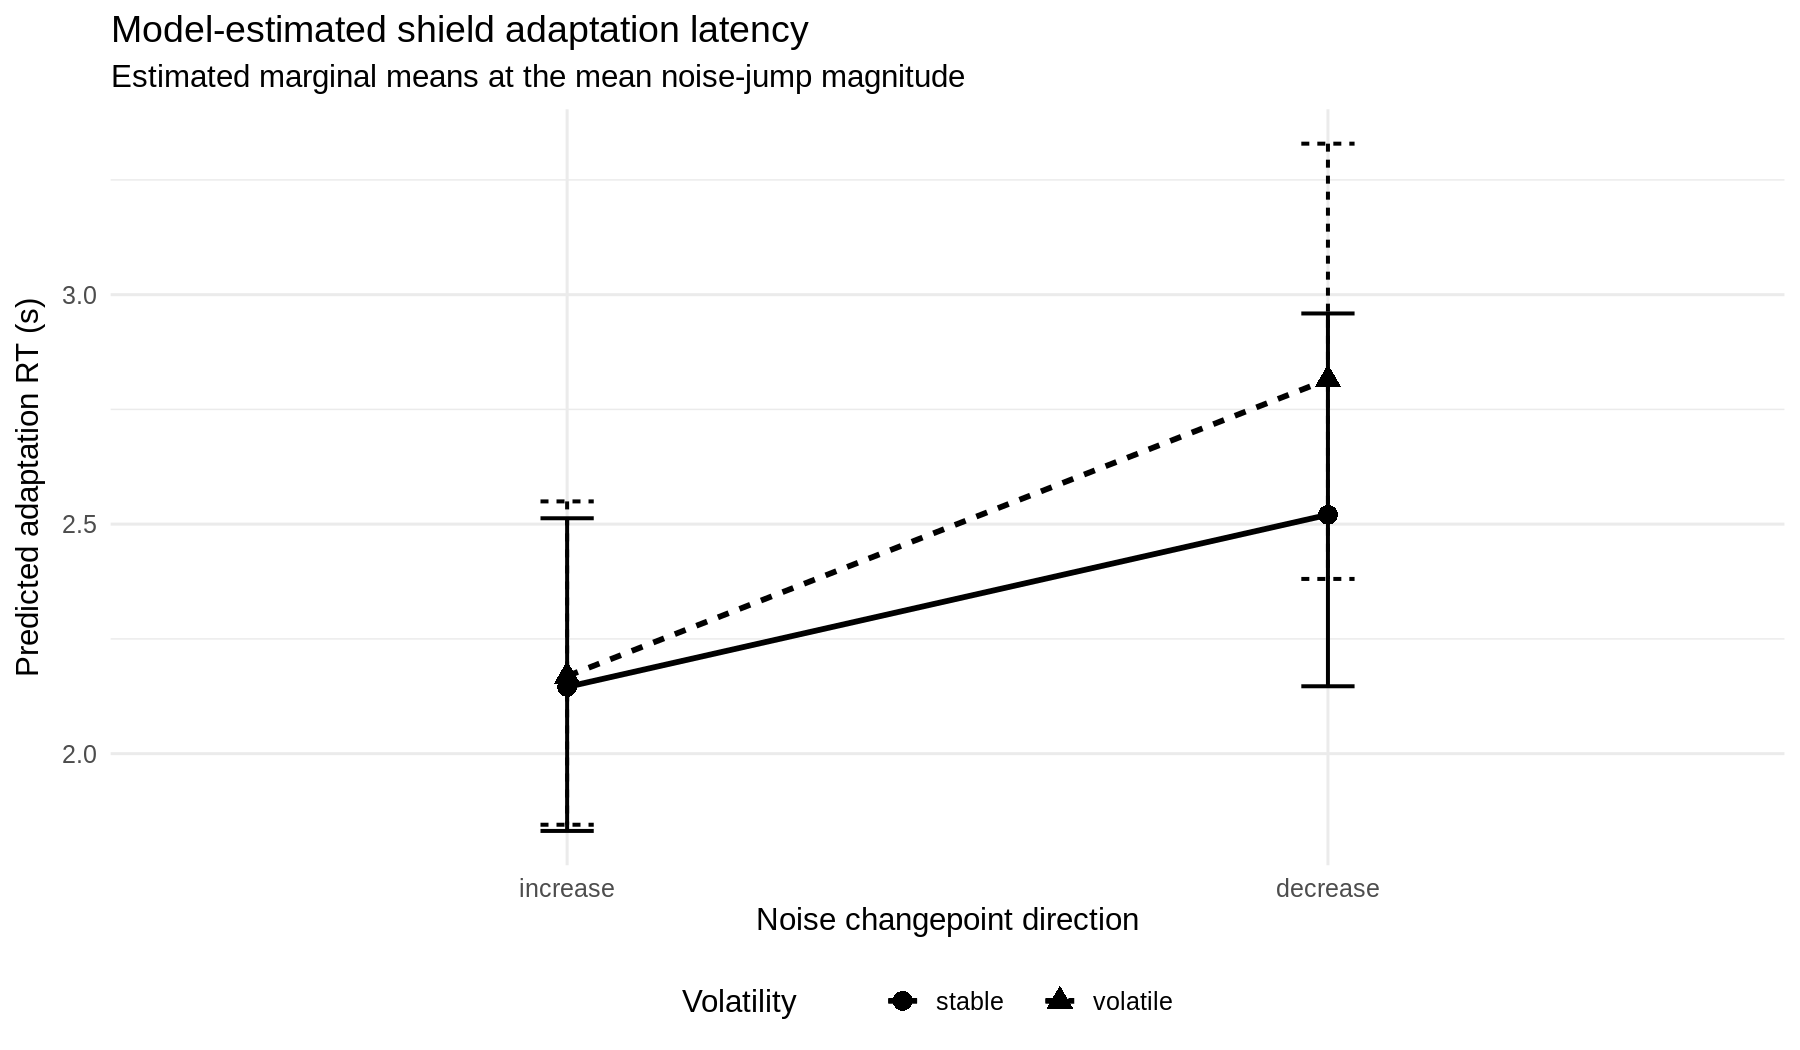

In [ ]:

p_interaction <- ggplot(
  emm_adapt,
  aes(
    x = direction,
    y = predicted_rt,
    group = volatility,
    linetype = volatility,
    shape = volatility
  )
) +
  geom_line(
    linewidth = 1.3
  ) +
  geom_point(
    size = 4
  ) +
  geom_errorbar(
    aes(
      ymin = lower_rt,
      ymax = upper_rt
    ),
    width = 0.07,
    linewidth = 0.9
  ) +
  labs(
    title = "Model-estimated shield adaptation latency",
    subtitle = "Estimated marginal means at the mean noise-jump magnitude",
    x = "Noise changepoint direction",
    y = "Predicted adaptation RT (s)",
    linetype = "Volatility",
    shape = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_interaction


## 12. Fixed-effect coefficient plot

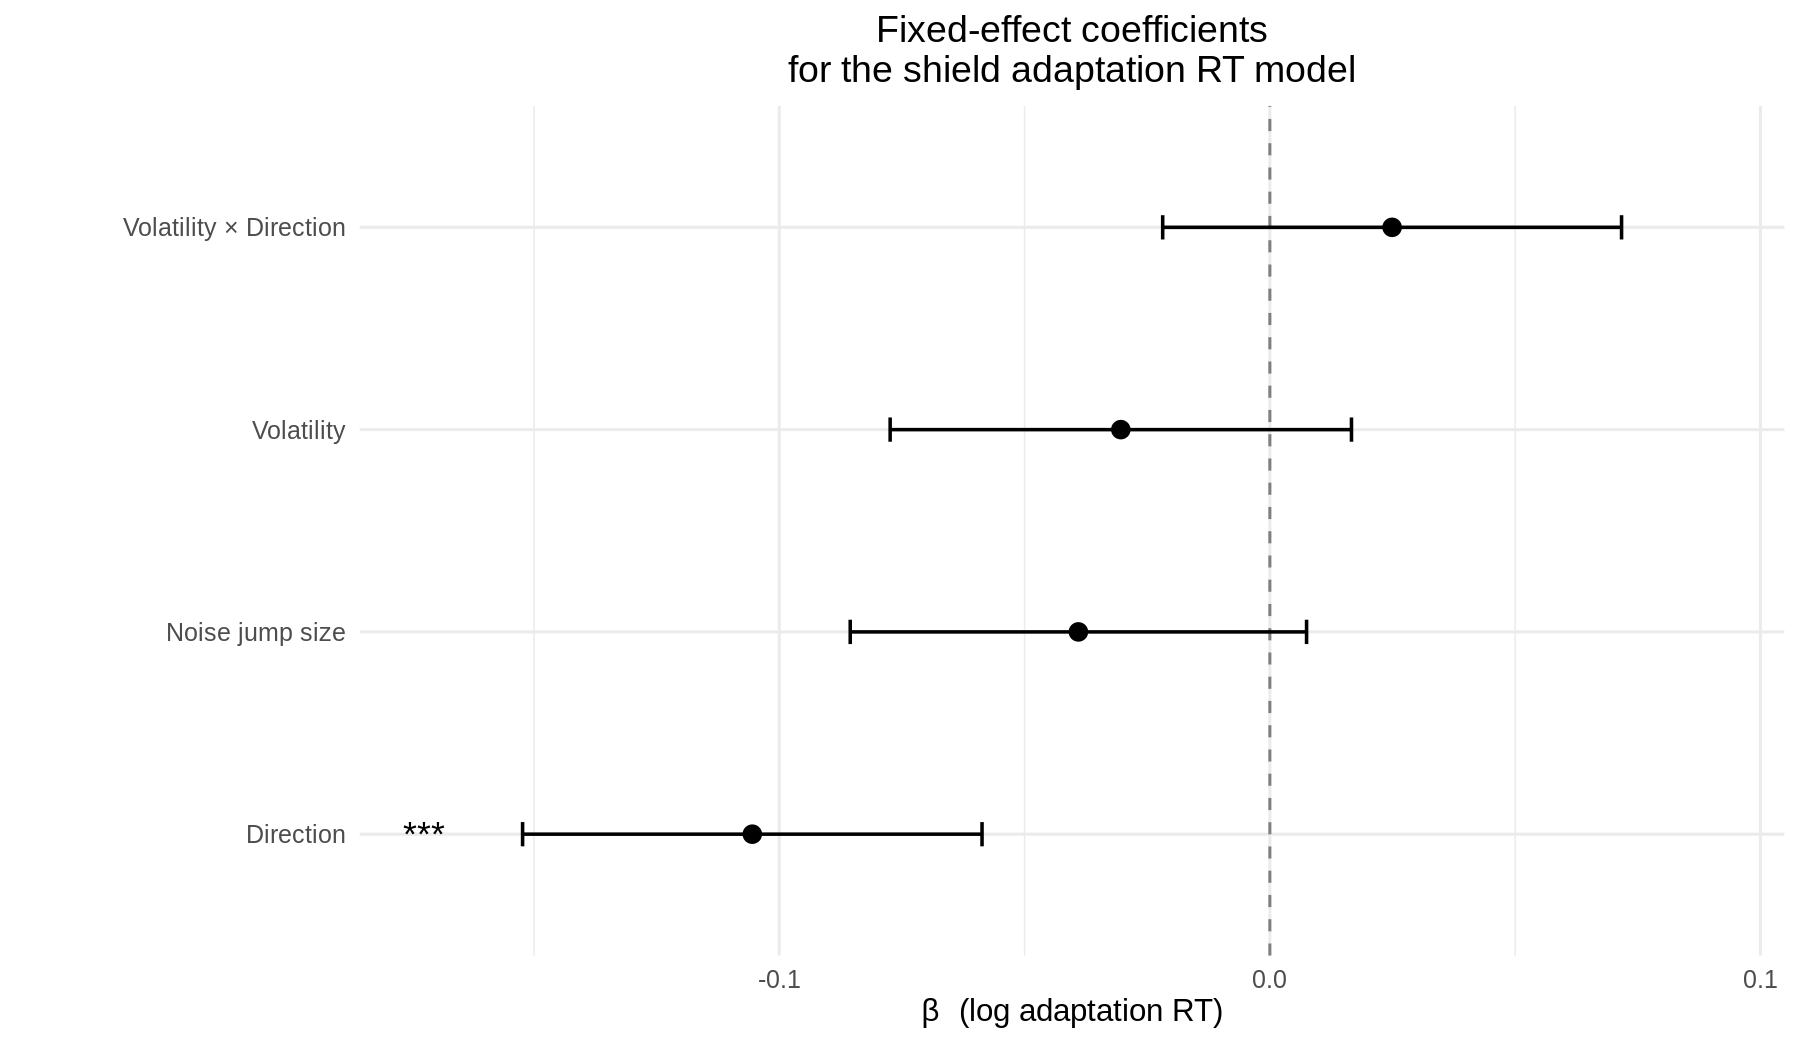

In [ ]:

beta_plot_data <- as.data.frame(
  summary(model_adapt_rt)$coefficients
)

beta_plot_data$Effect <- rownames(beta_plot_data)
rownames(beta_plot_data) <- NULL

beta_plot_data <- beta_plot_data %>%
  select(
    Effect,
    Estimate,
    `Std. Error`,
    `Pr(>|t|)`
  ) %>%
  rename(
    Beta = Estimate,
    SE = `Std. Error`,
    p = `Pr(>|t|)`
  ) %>%
  mutate(
    CI_low = Beta - 1.96 * SE,
    CI_high = Beta + 1.96 * SE,

    Significance = case_when(
      p < 0.001 ~ "***",
      p < 0.01  ~ "**",
      p < 0.05  ~ "*",
      TRUE      ~ ""
    ),

    Effect = recode(
      Effect,
      "volatility1" = "Volatility",
      "direction1" = "Direction",
      "noise_jump_size_z" = "Noise jump size",
      "volatility1:direction1" = "Volatility × Direction"
    )
  ) %>%
  filter(
    Effect != "(Intercept)"
  )

p_beta <- ggplot(
  beta_plot_data,
  aes(
    x = reorder(Effect, Beta),
    y = Beta
  )
) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed",
    color = "grey50"
  ) +
  geom_point(
    size = 3.5
  ) +
  geom_errorbar(
    aes(
      ymin = CI_low,
      ymax = CI_high
    ),
    width = 0.12,
    linewidth = 0.8
  ) +
  geom_text(
    aes(
      label = Significance,
      y = ifelse(
        Beta >= 0,
        CI_high + 0.02,
        CI_low - 0.02
      )
    ),
    size = 6
  ) +
  coord_flip() +
  labs(
    title = "Fixed-effect coefficients\nfor the shield adaptation RT model",
    x = NULL,
    y = expression(beta ~ "(log adaptation RT)")
  ) +
  theme(
    plot.title = element_text(
      hjust = 0.5
    )
  )

p_beta


## 13. Model diagnostics

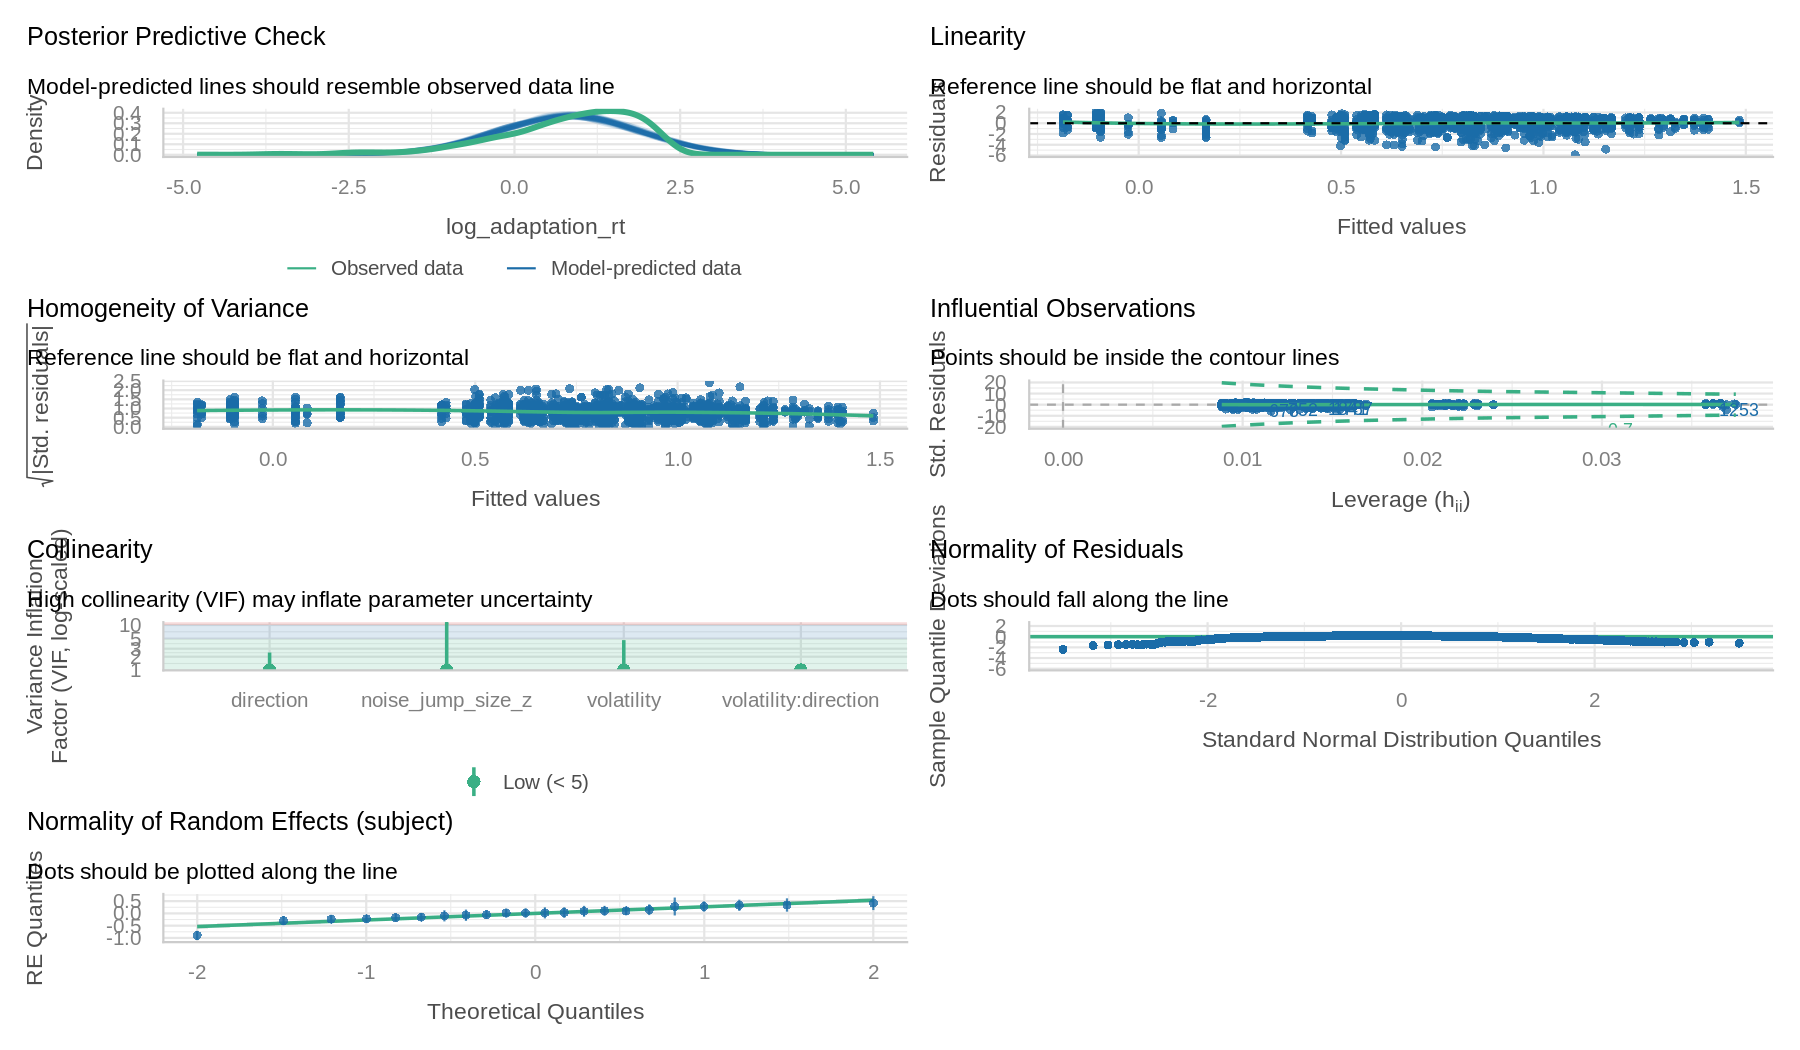

In [ ]:

# Residual and normality diagnostics
check_model(
  model_adapt_rt
)


In [ ]:

# Additional numerical checks
check_singularity(
  model_adapt_rt
)

check_collinearity(
  model_adapt_rt
)

performance(
  model_adapt_rt
)


[1] FALSE

Term,VIF,VIF_CI_low,VIF_CI_high,SE_factor,Tolerance,Tolerance_CI_low,Tolerance_CI_high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
volatility,1.007458,1.000015,4.635455,1.003722,0.9925971,0.2157286,0.9999847
direction,1.009117,1.000057,2.465093,1.004548,0.9909652,0.4056642,0.9999433
noise_jump_size_z,1.000651,1.000000,Inf,1.000325,0.9993494,0.0000000,1.0000000
volatility:direction,1.014726,1.000613,1.353924,1.007336,0.9854877,0.7385941,0.9993877


Model was not fitted with REML, however, `estimator = "REML"`. Set
  `estimator = "ML"` to obtain identical results as from `AIC()`.



AIC,AICc,BIC,R2_conditional,R2_marginal,ICC,RMSE,Sigma
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5368.888,5368.949,5407.518,0.09024299,0.01180017,0.07937951,1.010197,1.015427



## 14. Optional sensitivity analysis: model each noise transition directly

The primary model decomposes a transition into:

1. increase vs. decrease, and
2. transition magnitude (10 vs. 20 degrees).

However, transitions with the same magnitude are not necessarily equivalent (for example, `10→20` and `20→30`). The following sensitivity model treats the six transitions as a categorical factor.


In [ ]:

adapt_transition <- adapt_rt %>%
  droplevels()

contrasts(adapt_transition$volatility) <- contr.sum(2)
contrasts(adapt_transition$noise_transition) <- contr.sum(
  nlevels(adapt_transition$noise_transition)
)

model_transition <- lmer(
  log_adaptation_rt ~
    volatility * noise_transition +
    (1 | subject),
  data = adapt_transition,
  REML = FALSE
)

summary(model_transition)

anova(
  model_transition,
  type = 3,
  ddf = "Satterthwaite"
)


Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: log_adaptation_rt ~ volatility * noise_transition + (1 | subject)
   Data: adapt_transition

      AIC       BIC    logLik -2*log(L)  df.resid 
   5334.0    5411.2   -2653.0    5306.0      1828 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.6390 -0.5168  0.1618  0.7063  2.2213 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.0884   0.2973  
 Residual             1.0183   1.0091  
Number of obs: 1842, groups:  subject, 22

Fixed effects:
                                Estimate Std. Error         df t value Pr(>|t|)
(Intercept)                    9.104e-01  6.970e-02  2.329e+01  13.061 3.33e-12
volatility1                   -3.264e-02  2.742e-02  1.826e+03  -1.190 0.234112
noise_transition1             -1.235e-01  4.557e-02  1.824e+03  -2.710 0.006796
noise_transition2             -1.113e-01  7.956e-02  1.828e+03  -1.399 0.1619

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
volatility,1.442588,1.442588,1,1826.464,1.416639,2.341121e-01
noise_transition,38.536559,7.707312,5,1823.589,7.568676,4.783547e-07
volatility:noise_transition,8.792360,1.758472,5,1822.042,1.726841,1.251746e-01



## 15. Optional logistic mixed model: probability of obtaining a valid adaptation RT

This analysis uses **all noise changepoints**, including those for which the shield curve did not produce a valid half-peak crossing.

It is useful because the RT LMM is conditional on `valid_for_model == TRUE`. If validity differs systematically by experimental condition, that should be reported alongside the latency analysis.


In [ ]:

valid_glmm_data <- adapt_all %>%
  filter(
    !is.na(subject),
    !is.na(volatility),
    !is.na(direction),
    !is.na(noise_jump_size)
  ) %>%
  mutate(
    subject = factor(subject),
    noise_jump_size_z = as.numeric(
      scale(noise_jump_size)
    )
  )

contrasts(valid_glmm_data$volatility) <- contr.sum(2)
contrasts(valid_glmm_data$direction) <- contr.sum(2)

model_valid <- glmer(
  valid_for_model ~
    volatility * direction +
    noise_jump_size_z +
    (1 | subject),
  data = valid_glmm_data,
  family = binomial
)

summary(model_valid)


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: valid_for_model ~ volatility * direction + noise_jump_size_z +  
    (1 | subject)
   Data: valid_glmm_data

      AIC       BIC    logLik -2*log(L)  df.resid 
   3920.5    3957.1   -1954.3    3908.5      3261 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.1349 -0.8499  0.4346  0.7321  3.6748 

Random effects:
 Groups  Name        Variance Std.Dev.
 subject (Intercept) 0.8365   0.9146  
Number of obs: 3267, groups:  subject, 22

Fixed effects:
                       Estimate Std. Error z value Pr(>|z|)    
(Intercept)             0.29137    0.19903   1.464    0.143    
volatility1             0.22130    0.03911   5.659 1.53e-08 ***
direction1              0.17575    0.03905   4.500 6.79e-06 ***
noise_jump_size_z       0.36013    0.04036   8.923  < 2e-16 ***
volatility1:direction1 -0.05999    0.03898  -1.539    0.124    
---
Signif. codes:

## 16. Optional session sensitivity analysis

In [ ]:

adapt_session <- adapt_rt %>%
  mutate(
    session = factor(sessID)
  )

model_session <- lmer(
  log_adaptation_rt ~
    volatility * direction +
    noise_jump_size_z +
    session +
    (1 | subject),
  data = adapt_session,
  REML = FALSE
)

summary(model_session)

anova(
  model_session,
  type = 3,
  ddf = "Satterthwaite"
)


Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: log_adaptation_rt ~ volatility * direction + noise_jump_size_z +  
    session + (1 | subject)
   Data: adapt_session

      AIC       BIC    logLik -2*log(L)  df.resid 
   5335.8    5391.0   -2657.9    5315.8      1832 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.7262 -0.5144  0.1673  0.7187  2.3334 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.09064  0.3011  
 Residual             1.02354  1.0117  
Number of obs: 1842, groups:  subject, 22

Fixed effects:
                         Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)               0.81379    0.07873   36.16466  10.336 2.42e-12 ***
volatility1              -0.03199    0.02391 1827.58285  -1.338  0.18111    
direction1               -0.10676    0.02383 1822.12816  -4.480 7.92e-06 ***
noise_jump_size_z        -0.04004    0.02376 1822.51540  -1.685

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
volatility,1.831978,1.831978,1,1827.583,1.7898489,1.811110e-01
direction,20.545626,20.545626,1,1822.128,20.0731456,7.916566e-06
noise_jump_size_z,2.906773,2.906773,1,1822.515,2.8399266,9.211961e-02
session,13.399596,4.466532,3,1825.883,4.3638166,4.533289e-03
volatility:direction,1.016983,1.016983,1,1821.132,0.9935954,3.189976e-01


## 17. Save figures

In [ ]:

ggsave(
  "shield_adaptation_rt_boxplot.png",
  p_box,
  width = 9,
  height = 6,
  units = "in",
  dpi = 300
)

ggsave(
  "shield_adaptation_rt_interaction.png",
  p_interaction,
  width = 9,
  height = 6,
  units = "in",
  dpi = 300
)

ggsave(
  "shield_adaptation_rt_beta_plot.png",
  p_beta,
  width = 9,
  height = 5.5,
  units = "in",
  dpi = 300
)



## Reporting template

After running the notebook, the primary result can be reported in the following form:

> A linear mixed-effects model was used to examine shield-size adaptation latency following changes in observation noise. Adaptation RTs were log-transformed prior to analysis. The model included environmental volatility, the direction of the noise change (increase vs. decrease), their interaction, and standardized noise-jump magnitude as fixed effects, with participant-specific random intercepts. [Insert Type-III tests and coefficient estimates here.] Estimated marginal means were subsequently used to characterise significant interactions on the original reaction-time scale.

If the logistic validity model reveals condition effects, also report that the probability of obtaining a valid half-peak latency differed across conditions.
